# Nova Markets — Follow-up analysis

This notebook **validates, corrects, and extends** the original submission. It deliberately reuses the same core cleaning and filtering logic so the changes are easy to explain.

The original notebook remains unchanged. The follow-up adds only the work that was missing or needed correction:

1. Reconcile the filtered orders with the merchant dashboard.
2. Quantify the NBLX traffic-mix effect.
3. Correct the Japanese-card definition to `country = JP` and `payment_method = CARD`.
4. Analyse SORVA decline reasons before and after June 11.
5. Check whether the June 8 NBLX risk-rule change increased filtering.
6. Reconstruct missing USD values and estimate potentially lost approved volume.


In [2]:
from pathlib import Path
import json
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_DIR = Path(".")

orders = pd.read_csv(
    DATA_DIR / "orders.csv",
    parse_dates=["created_at", "completed_at"]
)
dashboard = pd.read_csv(
    DATA_DIR / "merchant_dashboard_export.csv",
    parse_dates=["date"]
)
fx = pd.read_csv(DATA_DIR / "fx_rates.csv", parse_dates=["date"])
routes = json.loads((DATA_DIR / "routes.json").read_text())["routes"]

print("Orders shape:", orders.shape)
print("Duplicate rows:", orders.duplicated().sum())
print("Duplicate order IDs:", orders["order_id"].duplicated().sum())


Orders shape: (59386, 15)
Duplicate rows: 0
Duplicate order IDs: 0


## 1. Reuse the original preparation logic

The following steps are intentionally the same as the original analysis: normalize inconsistent text, select Nova SALE transactions, use UTC+8 for merchant reporting, exclude partial June 29–30 data, and use APPROVED/DECLINED for provider approval.


In [4]:
text_columns = [
    "merchant_id", "route_id", "processor", "order_type",
    "status", "currency", "customer_country",
    "payment_method", "decline_reason"
]

for column in text_columns:
    orders[column] = (
        orders[column]
        .astype("string")
        .str.strip()
        .str.upper()
    )

dashboard["payment_method"] = (
    dashboard["payment_method"]
    .astype("string")
    .str.strip()
    .str.upper()
)

nova = orders[
    (orders["merchant_id"] == "NOVA-FX") &
    (orders["order_type"] == "SALE")
].copy()

nova["local_date"] = (
    nova["created_at"] + pd.Timedelta(hours=8)
).dt.normalize()

nova = nova[nova["local_date"] <= "2026-06-28"].copy()

final = nova[
    nova["status"].isin(["APPROVED", "DECLINED"])
].copy()

may = final[
    (final["local_date"] >= "2026-05-01") &
    (final["local_date"] < "2026-06-01")
].copy()

june = final[
    (final["local_date"] >= "2026-06-01") &
    (final["local_date"] <= "2026-06-28")
].copy()

def approval_summary(data):
    attempts = len(data)
    approved = data["status"].eq("APPROVED").sum()

    return pd.Series({
        "attempts": attempts,
        "approved": approved,
        "approval_rate": approved / attempts
    })

period_summary = pd.DataFrame({
    "May": approval_summary(may),
    "June 1-28": approval_summary(june)
}).T

display(period_summary.style.format({
    "approval_rate": "{:.1%}"
}))

,attempts,approved,approval_rate
May,6240.000000,4996.000000,80.1%
June 1-28,8156.000000,5904.000000,72.4%


## 2. Dashboard reconciliation

The original notebook loaded the dashboard but did not show the comparison. Here the cleaned orders are aggregated to the dashboard grain: local date and payment method.


In [5]:
calculated_dashboard = (
    final.groupby(["local_date", "payment_method"])
    .agg(
        attempts_calculated=("order_id", "size"),
        approved_calculated=("status", lambda x: x.eq("APPROVED").sum())
    )
    .reset_index()
)

dashboard_complete = (
    dashboard[dashboard["date"] <= "2026-06-28"]
    .rename(columns={
        "date": "local_date",
        "attempts": "attempts_dashboard",
        "approved": "approved_dashboard"
    })
)

reconciliation = calculated_dashboard.merge(
    dashboard_complete,
    on=["local_date", "payment_method"],
    how="outer",
    indicator=True,
    validate="one_to_one"
)

reconciliation["attempt_difference"] = (
    reconciliation["attempts_calculated"] -
    reconciliation["attempts_dashboard"]
)
reconciliation["approved_difference"] = (
    reconciliation["approved_calculated"] -
    reconciliation["approved_dashboard"]
)

dashboard_check = pd.Series({
    "groups_compared": len(reconciliation),
    "groups_present_in_both": reconciliation["_merge"].eq("both").sum(),
    "total_absolute_attempt_difference": reconciliation["attempt_difference"].abs().sum(),
    "total_absolute_approved_difference": reconciliation["approved_difference"].abs().sum(),
})
dashboard_check


groups_compared                       267
groups_present_in_both                267
total_absolute_attempt_difference       0
total_absolute_approved_difference      0
dtype: int64

**Interpretation:** all comparable daily payment-method groups match exactly. This validates the merchant, SALE, status, timezone, and complete-date filters.


## 3. Quantify the NBLX traffic-mix effect

The original submission correctly identified NBLX as the main driver, but did not quantify its contribution. The calculation below uses the established-route June rate as a transparent counterfactual—not as a proven target for NBLX.


In [12]:
# -------------------------
# Existing routes vs new NBLX route
# -------------------------

new_route = june[june["route_id"] == "NBLX-07"]
existing_routes = june[june["route_id"] != "NBLX-07"]

route_comparison = pd.DataFrame({
    "NBLX-07": {
        "Attempts": len(new_route),
        "Approved": new_route["status"].eq("APPROVED").sum(),
        "Traffic share": len(new_route) / len(june),
        "Approval rate": new_route["status"].eq("APPROVED").mean(),
    },
    "Existing routes": {
        "Attempts": len(existing_routes),
        "Approved": existing_routes["status"].eq("APPROVED").sum(),
        "Traffic share": len(existing_routes) / len(june),
        "Approval rate": existing_routes["status"].eq("APPROVED").mean(),
    }
}).T

display(route_comparison.style.format({
    "Attempts": "{:,.0f}",
    "Approved": "{:,.0f}",
    "Traffic share": "{:.1%}",
    "Approval rate": "{:.1%}",
}))

,Attempts,Approved,Traffic share,Approval rate
NBLX-07,"2,182","1,171",26.8%,53.7%
Existing routes,"5,974","4,733",73.2%,79.2%


In [13]:
# -------------------------
# Estimate NBLX impact
# -------------------------

existing_rate = existing_routes["status"].eq("APPROVED").mean()

expected_approved = len(new_route) * existing_rate
actual_approved = new_route["status"].eq("APPROVED").sum()

approval_gap = expected_approved - actual_approved
overall_effect = approval_gap / len(june)

impact = pd.DataFrame({
    "Expected approvals": [expected_approved],
    "Actual approvals": [actual_approved],
    "Estimated approval gap": [approval_gap],
    "Effect on overall June rate": [overall_effect],
})

display(
    impact.style.format({
        "Expected approvals": "{:,.0f}",
        "Actual approvals": "{:,.0f}",
        "Estimated approval gap": "{:,.0f}",
        "Effect on overall June rate": "{:.1%}",
    })
)

,Expected approvals,Actual approvals,Estimated approval gap,Effect on overall June rate
0,"1,729","1,171",558,6.8%


**Interpretation:** If NBLX had performed at the same 79.2% approval rate as the established routes, we would expect approximately 1,729 approvals. The actual number was 1,171, creating an estimated gap of 558 approvals. This gap is equivalent to about 6.8 percentage points of the overall June approval rate. However, this is a counterfactual estimate, not a proven loss, because NBLX served different traffic.


## 4. Correct the SORVA Japanese-card segment

The original analysis used JPY currency as a proxy. The more precise definition follows the operational event: `SORVA-14`, customer country `JP`, and payment method `CARD`.


In [14]:
sorva_jp_cards = final[
    (final["route_id"] == "SORVA-14") &
    (final["customer_country"] == "JP") &
    (final["payment_method"] == "CARD")
].copy()

sorva_periods = {
    "May": sorva_jp_cards[
        (sorva_jp_cards["local_date"] >= "2026-05-01") &
        (sorva_jp_cards["local_date"] < "2026-06-01")
    ],
    "June 1-10": sorva_jp_cards[
        (sorva_jp_cards["local_date"] >= "2026-06-01") &
        (sorva_jp_cards["local_date"] < "2026-06-11")
    ],
    "June 11-28": sorva_jp_cards[
        (sorva_jp_cards["local_date"] >= "2026-06-11") &
        (sorva_jp_cards["local_date"] <= "2026-06-28")
    ],
}

sorva_summary = []
for period, data in sorva_periods.items():
    sorva_summary.append({
        "period": period,
        "attempts": len(data),
        "approved": data["status"].eq("APPROVED").sum(),
        "approval_rate_pct": data["status"].eq("APPROVED").mean() * 100,
        "do_not_honor_count": data["decline_reason"].eq("DO_NOT_HONOR").fillna(False).sum(),
        "do_not_honor_share_pct": data["decline_reason"].eq("DO_NOT_HONOR").fillna(False).mean() * 100,
    })

sorva_summary = pd.DataFrame(sorva_summary).set_index("period").round(1)

may_sorva_rate = sorva_periods["May"]["status"].eq("APPROVED").mean()
post_sorva = sorva_periods["June 11-28"]
estimated_lost_approvals = (
    len(post_sorva) * may_sorva_rate -
    post_sorva["status"].eq("APPROVED").sum()
)

display(sorva_summary)
print("Estimated potentially lost approvals:", round(estimated_lost_approvals))


,attempts,approved,approval_rate_pct,do_not_honor_count,do_not_honor_share_pct
period,,,,,
May,444,333,75.0000,26,5.9000
June 1-10,189,142,75.1000,14,7.4000
June 11-28,324,181,55.9000,87,26.9000


Estimated potentially lost approvals: 62


**Interpretation:** approval stayed near 75% through June 10, then fell to about 56% after the June 11 event. `DO_NOT_HONOR` rose from 5.9% of May attempts to 26.9% after June 11. The timing supports a connection, but exact affected BIN ranges are still needed to establish stronger causal evidence.


## 5. Did the June 8 NBLX risk-rule change increase filtering?

Filter rate is defined here as FILTERED attempts divided by all NBLX attempts in the period.


In [15]:
nblx_all = nova[
    (nova["route_id"] == "NBLX-07") &
    (nova["local_date"] >= "2026-06-02")
].copy()

risk_periods = {
    "June 2-7": nblx_all[nblx_all["local_date"] < "2026-06-08"],
    "June 8-28": nblx_all[nblx_all["local_date"] >= "2026-06-08"],
}

risk_summary = pd.DataFrame([
    {
        "period": period,
        "all_attempts": len(data),
        "filtered": data["status"].eq("FILTERED").sum(),
        "filter_rate_pct": data["status"].eq("FILTERED").mean() * 100,
    }
    for period, data in risk_periods.items()
]).set_index("period").round(1)

risk_summary


,all_attempts,filtered,filter_rate_pct
period,,,
June 2-7,200,47,23.5000
June 8-28,2681,608,22.7000


**Interpretation:** the observed filter rate did not increase after June 8. This does not prove that the rule had no effect; traffic risk may also have changed. Fraud and chargeback outcomes are required before recommending that the rule be relaxed.


## 6. Reconstruct USD values and estimate lost approved volume

Assumptions:

- Use the transaction's original UTC date for the FX quote.
- Use the latest prior available rate for weekends.
- For pairs quoted as USD→JPY, invert the rate before converting JPY to USD.
- Preserve supplied `amount_usd` values and fill only missing ones.
- Estimate approved-volume impact for the corrected SORVA Japanese-card segment; do not label it profit loss.


In [16]:
fx_to_usd = fx.copy()
fx_to_usd["currency"] = fx_to_usd["from_currency"]
fx_to_usd["to_usd_rate"] = fx_to_usd["rate"]

inverse_quote = (
    fx_to_usd["from_currency"].eq("USD") &
    fx_to_usd["to_currency"].ne("USD")
)
fx_to_usd.loc[inverse_quote, "currency"] = (
    fx_to_usd.loc[inverse_quote, "to_currency"]
)
fx_to_usd.loc[inverse_quote, "to_usd_rate"] = (
    1 / fx_to_usd.loc[inverse_quote, "rate"]
)
fx_to_usd = fx_to_usd[["date", "currency", "to_usd_rate"]]

nova_fx = nova.reset_index().rename(columns={"index": "original_index"})
nova_fx["fx_date"] = nova_fx["created_at"].dt.normalize()

converted_parts = []
for currency, data in nova_fx.groupby("currency", dropna=False):
    data = data.sort_values("fx_date").copy()
    if currency == "USD":
        data["to_usd_rate"] = 1.0
    else:
        currency_rates = (
            fx_to_usd[fx_to_usd["currency"] == currency]
            .sort_values("date")
        )
        data = pd.merge_asof(
            data,
            currency_rates,
            left_on="fx_date",
            right_on="date",
            direction="backward"
        )
    converted_parts.append(data)

nova_fx = (
    pd.concat(converted_parts, ignore_index=True)
    .sort_values("original_index")
)
nova_fx["calculated_amount_usd"] = (
    nova_fx["amount"] * nova_fx["to_usd_rate"]
)
nova_fx["amount_usd_filled"] = (
    nova_fx["amount_usd"]
    .fillna(nova_fx["calculated_amount_usd"])
)

missing_check = pd.Series({
    "missing_amount_usd_before": nova_fx["amount_usd"].isna().sum(),
    "missing_amount_usd_after": nova_fx["amount_usd_filled"].isna().sum(),
})
missing_check


missing_amount_usd_before    3868
missing_amount_usd_after        0
dtype: int64

In [17]:
sorva_value = nova_fx[
    (nova_fx["route_id"] == "SORVA-14") &
    (nova_fx["customer_country"] == "JP") &
    (nova_fx["payment_method"] == "CARD") &
    (nova_fx["status"].isin(["APPROVED", "DECLINED"]))
].copy()

sorva_value_may = sorva_value[
    (sorva_value["local_date"] >= "2026-05-01") &
    (sorva_value["local_date"] < "2026-06-01")
]
sorva_value_post = sorva_value[
    (sorva_value["local_date"] >= "2026-06-11") &
    (sorva_value["local_date"] <= "2026-06-28")
]

may_attempted_volume = sorva_value_may["amount_usd_filled"].sum()
may_approved_volume = sorva_value_may.loc[
    sorva_value_may["status"] == "APPROVED",
    "amount_usd_filled"
].sum()
may_value_approval_rate = may_approved_volume / may_attempted_volume

post_attempted_volume = sorva_value_post["amount_usd_filled"].sum()
post_actual_approved_volume = sorva_value_post.loc[
    sorva_value_post["status"] == "APPROVED",
    "amount_usd_filled"
].sum()
post_expected_approved_volume = (
    post_attempted_volume * may_value_approval_rate
)
potentially_lost_approved_volume = (
    post_expected_approved_volume - post_actual_approved_volume
)

financial_summary = pd.Series({
    "May attempted volume (USD)": may_attempted_volume,
    "May approved volume (USD)": may_approved_volume,
    "May value approval rate (%)": may_value_approval_rate * 100,
    "Post-change attempted volume (USD)": post_attempted_volume,
    "Post-change actual approved volume (USD)": post_actual_approved_volume,
    "Post-change expected approved volume (USD)": post_expected_approved_volume,
    "Potentially lost approved volume (USD)": potentially_lost_approved_volume,
}).round(2)
financial_summary


May attempted volume (USD)                   747,336.8700
May approved volume (USD)                    497,236.8300
May value approval rate (%)                       66.5300
Post-change attempted volume (USD)           486,763.7500
Post-change actual approved volume (USD)     258,369.1700
Post-change expected approved volume (USD)   323,865.8100
Potentially lost approved volume (USD)        65,496.6400
dtype: float64

**Interpretation:** the estimate is approximately **$65.5k in potentially lost approved payment volume** for the affected SORVA segment. It is not confirmed revenue or profit loss because merchant margin, fees, chargebacks, and successful later retries are unavailable.


## 7. Daily approval-rate view with operational events


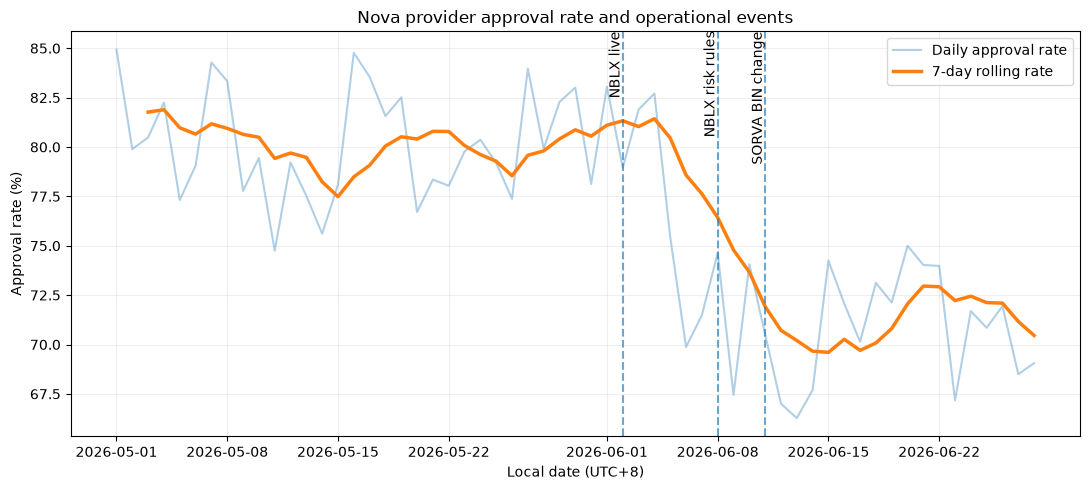

In [21]:
daily = (
    final[final["local_date"] >= "2026-05-01"]
    .groupby("local_date")
    .agg(
        attempts=("order_id", "size"),
        approved=("status", lambda x: x.eq("APPROVED").sum())
    )
)
daily["approval_rate"] = daily["approved"] / daily["attempts"]
daily["rolling_7d"] = daily["approval_rate"].rolling(7, min_periods=3).mean()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(daily.index, daily["approval_rate"] * 100, alpha=0.35, label="Daily approval rate")
ax.plot(daily.index, daily["rolling_7d"] * 100, linewidth=2.5, label="7-day rolling rate")

events = {
    "2026-06-02": "NBLX live",
    "2026-06-08": "NBLX risk rules",
    "2026-06-11": "SORVA BIN change",
}
for date, label in events.items():
    event_date = pd.Timestamp(date)
    ax.axvline(event_date, linestyle="--", alpha=0.65)
    ax.text(event_date, ax.get_ylim()[1], label, rotation=90, va="top", ha="right")

ax.set_title("Nova provider approval rate and operational events")
ax.set_ylabel("Approval rate (%)")
ax.set_xlabel("Local date (UTC+8)")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()


## Final follow-up conclusions

- The original 80.1% to 72.4% decline is confirmed.
- All 267 comparable dashboard groups match exactly, validating the core filters.
- NBLX represented about 27% of June final attempts at a 53.7% provider approval rate. Under the established-route counterfactual, it is associated with about 6.8 of the 7.7 percentage-point decline.
- The corrected SORVA segment fell from 75.0% in May and 75.1% on June 1–10 to 55.9% after June 11. The corrected approval-gap estimate is 62, not 64.
- `DO_NOT_HONOR` rose sharply after June 11, supporting—but not proving—a connection to the BIN event.
- NBLX's observed filter rate did not increase after the June 8 rule change. Fraud and chargeback data are still required to evaluate the rule.
- The affected SORVA segment shows approximately $65.5k in potentially lost approved payment volume, not confirmed profit loss.
